# Fixed axes

`fixed_axes={"t": 10}` pins a stored axis to one index and removes it, so this 4D (`t z y x`) time series samples like a 3D volume at frame 10, the frame its labels annotate. `t` is left out of `output_axes`, `patch_size` and `resolutions`.

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from miao import MiaoConfig, VolumeDataset

pth = "/groups/miaai/miaai/lmd-v0.0.1/data/lm-zebrafish-Betzig-mosaic-example_annotations_Thayer/crop-001_dsr_timeseries_48t_1c.zarr"

cfg = MiaoConfig(
    volumes=[dict(
        name="zebrafish",
        path=pth,
        image_key="raw",  # stored as t c z y x
        label_key="labels/manual_gt-cell-t25_postproofread",
        zarr_version="zarr3",
        fixed_axes={"t": 25},
    )],
    resolutions=[[1, 1, 1]],  # pyramid level s1
    output_axes="lcxyz",
    patch_size=[128, 128, 128],
)
dataset = VolumeDataset(cfg)

VolumeDataset: 1 volume(s), random, 1000 samples/epoch, patch_size=[128, 128, 128]
  [zebrafish]
    image: axes='czyx', shape=[1, 152, 508, 1466], dtype=uint16
    scale 0: resolution=[1.0, 1.0, 1.0] -> level 0 (voxel_size=[1.0, 1.0, 1.0], read [128, 128, 128] -> resample to [128, 128, 128])
    label: axes='czyx', shape=[1, 152, 508, 1466], dtype=uint32 -> int64
    sampling: p=1, size=1.132e+08 reachable voxels, center_range=[[64, 64, 64], [88, 444, 1402]]
    normalize: uint16 -> [0, 1] (divide by dtype max)
  output: axes='lcxyz', tensor_shape=(L, C, X, Y, Z)


(1, 1, 128, 128, 128) (1, 128, 128, 128)


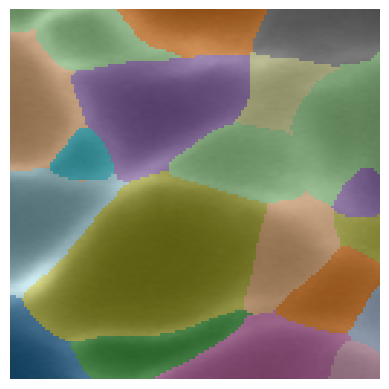

In [9]:
sample = dataset[1]
print(tuple(sample["img"].shape), tuple(sample["label"].shape))   # (L, C, Z, Y, X), (L, Z, Y, X)

img = sample["img"][0, 0, 16].numpy()
lab = sample["label"][0, 16].numpy()
plt.imshow(img, cmap="gray")
plt.imshow(np.ma.masked_equal(lab, 0) % 20, cmap="tab20", alpha=0.5, interpolation="nearest")
plt.axis("off")
plt.show()